# Physics-Informed Neural Networks (PINNs) for a 1D Poisson Equation

Arnaja Mitra  

This notebook is created following the 1D PINN Poisson example developed by **Xiaofeng (George) Xu** and available in the GitHub repository:

https://github.com/georgexxu/Data-driven-Model-Discovery-Neural-Operators/blob/main/pinns/pinn.py

The purpose of this notebook is to provide a step-by-step introduction to PINNs for solving boundary value problems, with emphasis on loss function formulation, automatic differentiation, and the training procedure.

## Imports and setup
 
 We import PyTorch, plotting tools, and set the computation device. If GPU is available, the code uses GPU; otherwise, it uses CPU.

In [159]:
import sys
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Python: /opt/anaconda3/bin/python
PyTorch: 2.4.1
Device: cpu


## Reproducibility

 To ensure that results are reproducible across multiple runs, we fix the random seed for Python, NumPy, and PyTorch.

In [161]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Define the PINN model

A Physics-Informed Neural Network (PINN) approximates the solution of a differential equation using a neural network. In this example, the neural network takes the spatial coordinate $x$ as input and produces an approximation of the solution $u(x)$.

The boundary value problem under consideration is given by $u''(x) + \sin(\omega x) = 0, \; 0 < x < 1,$ subject to the homogeneous Dirichlet boundary conditions $u(0)=u(1)=0$. To satisfy the boundary conditions, the neural network output is multiplied by the function $x(1-x)$, giving $u_\theta(x)=x(1-x)N_\theta(x)$, where $N_\theta(x)$ denotes the neural network with trainable parameters $\theta$. Since $x(1-x)=0$ at $x=0$ and $x=1$, the boundary conditions are automatically enforced. This approach is known as a **hard boundary constraint**.

The neural network architecture consists of:
- an input layer with one neuron corresponding to the spatial coordinate $x$,
- a hidden layer with n=100 neurons,
- a nonlinear activation function ($\tanh$),
- an output layer that approximates the solution.

The trainable parameters are determined by minimizing the residual of the boundary value problem. The residual is evaluated at a set of collocation points within the computational domain. Throughout this tutorial, we use $N_c=500$ uniformly spaced interior collocation points in the interval $(0,1)$.

In [164]:
class PINN(nn.Module):
    def __init__(self, hidden_size, activation="tanh", relu_k=1):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.activation = activation
        self.relu_k = relu_k

    def _activate(self, z):
        if self.activation == "tanh":
            return torch.tanh(z)
        if self.activation == "relu":
            return torch.relu(z).pow(self.relu_k)
        raise ValueError(f"Unknown activation: {self.activation!r}. Use 'tanh' or 'relu'.")

    def forward(self, x):
        u = self._activate(self.fc1(x))
        u = self.fc2(u)
        return x * (1 - x) * u

## Define PDE loss

Let $u_\theta(x)$ denote the PINN approximation of the solution. The derivatives of $u_\theta$ with respect to $x$ are computed using automatic differentiation. Hence, the residual of the differential equation is given by $R(x)=u_\theta''(x)+\sin(\omega x)$.

The corresponding loss function is defined as $\mathcal{L}_{\mathrm{PDE}}=\frac{1}{N_c}\sum_{i=1}^{N_c}\left[u_\theta''(x_i)+\sin(\omega x_i)\right]^2$, where $N_c$ is the number of interior collocation points.

Since the boundary conditions are imposed exactly through the ansatz $u_\theta(x)=x(1-x)N_\theta(x)$, there is no need to include an additional boundary loss term. Thus, the loss function used in this example consists only of the PDE residual loss.

In [166]:
def pde_loss(model, x, b):
    u = model(x)

    du = torch.autograd.grad(u, x,torch.ones_like(u),create_graph=True)[0]

    d2u = torch.autograd.grad(du, x,torch.ones_like(du),create_graph=True)[0]

    residual = d2u.squeeze() + b
    return torch.mean(residual ** 2)

## Define relative $L^2$ error

To assess the accuracy of the PINN approximation, we compare the predicted solution with the exact solution on a set of test points in the interval $(0,1)$.

Let $u_\theta(x)$ denote the PINN solution and let $u_{\mathrm{exact}}(x)$ denote the exact solution. The relative $L^2$ error is defined by $\frac{\|u_\theta-u_{\mathrm{exact}}\|_2}{\|u_{\mathrm{exact}}\|_2}$.

This quantity measures the size of the prediction error relative to the size of the exact solution. A smaller relative $L^2$ error indicates that the PINN solution is closer to the exact solution.

In [169]:
def relative_l2_error(model, x_test, u_test, l2_norm_exact):
    with torch.no_grad():
        u_pred = model(x_test.view(-1, 1)).squeeze()
        return torch.norm(u_pred - u_test) / l2_norm_exact

## Define the parameters

In this example, we take $\omega=10$, which determines the oscillatory forcing term $\sin(\omega x)$. The neural network uses one hidden layer with $100$ neurons and the hyperbolic tangent activation function.

The model is first trained using the Adam optimizer for $6000$ epochs. The training progress is printed every $1000$ epochs. After Adam training, the solution is further refined using the L-BFGS optimizer for $100$ steps, with a maximum of $20$ internal iterations per step.

**Note.** Common activation functions used in PINNs include the $\tanh$, sigmoid, ReLU, and sinusoidal activation functions, among others. In this example, we employ the $\tanh$ activation function.

In [175]:
# (Recall) PDE: u'' + sin(omega x) = 0 on (0, 1)
# Boundary conditions: u(0) = u(1) = 0

omega = 10.0

hidden_size = 100
activation = "tanh"   # choices: "tanh" or "relu" 
relu_k = 2            # used only if activation = "relu"

num_epochs = 6000
print_interval = 1000

lbfgs_steps = 100
lbfgs_max_iter = 20

## Create collocation points

The command $\mathrm{torch.linspace(0,1,N_c+2)}$ first generates points on the closed interval $[0,1]$. The endpoints are then removed using `[1:-1]`, since the boundary conditions are already enforced exactly through the ansatz $u_\theta(x)=x(1-x)N_\theta(x)$.

The variable `x` stores the collocation points in column-vector form and is marked with `requires_grad_(True)` so that PyTorch can compute derivatives of the network output with respect to $x$. The term $b(x)=\sin(\omega x)$ is then evaluated at the collocation points and used in the PDE residual.

In [177]:
n_interior = 500

xc = torch.linspace(0, 1, n_interior + 2)[1:-1].to(device)

x = xc.view(-1, 1).clone().requires_grad_(True)

b = torch.sin(omega * xc)

## Exact solution for comparison

For validation purposes, the PINN approximation is compared with the exact solution of the boundary value problem. For our problem, the exact solution is $u(x)=\frac{\sin(\omega x)}{\omega^2}-\frac{x\sin(\omega)}{\omega^2}$.

The exact solution is evaluated at 1000 uniformly distributed test points in the interval $(0,1)$. These test points are used for validation and do not participate in the training process. The exact solution and the PINN approximation are compared on this set of test points to compute the relative $L^2$ error.

In [179]:
u_exact = (torch.sin(omega * xc) / omega**2- xc * torch.sin(torch.tensor(omega, device=device)) / omega**2)

n_test = 1002

x_test = torch.linspace(0, 1, n_test)[1:-1].to(device)

u_test = (torch.sin(omega * x_test) / omega**2- x_test * torch.sin(torch.tensor(omega, device=device)) / omega**2)

l2_norm_exact = torch.norm(u_test)

## Initialize model and optimizer

The Adam optimizer is then used to update the trainable parameters of the neural network. The learning rate is chosen as $10^{-3}$.

The lists `loss_history` and `l2_history` are used to store the PDE loss and the relative $L^2$ error during training. These stored values will later be used to visualize the training performance of the PINN model.

In [185]:
model = PINN(hidden_size=hidden_size,activation=activation,relu_k=relu_k).to(device)

adam_optimizer = optim.Adam(model.parameters(), lr=1e-3)

loss_history = []
l2_history = []

print(f"Activation: {activation}" + (f" (k={relu_k})" if activation == "relu" else ""))

Activation: tanh


## Train with Adam

The PINN is first trained using the Adam optimizer. At each epoch, the PDE residual loss is computed, backpropagation is used to calculate the gradients, and the network parameters are updated.

During training, the relative $L^2$ error is also evaluated on the test points and stored together with the loss value. The progress is printed every $1000$ epochs, as well as at the first and final epochs. At the end of this step, the final and best relative $L^2$ errors obtained during Adam training are reported.

In [188]:
print("=== Adam ===")

t0 = time.time()

for epoch in range(1, num_epochs + 1):
    loss = pde_loss(model, x, b)

    adam_optimizer.zero_grad()
    loss.backward()
    adam_optimizer.step()

    rel_l2 = relative_l2_error(model, x_test, u_test, l2_norm_exact)

    loss_history.append(loss.item())
    l2_history.append(rel_l2.item())

    if epoch % print_interval == 0 or epoch == 1 or epoch == num_epochs:
        print(f"Epoch {epoch:6d} | loss={loss.item():.4e} | rel L2={rel_l2.item():.4e}")

adam_time = time.time() - t0
adam_best_l2 = min(l2_history)
adam_final_loss = loss_history[-1]
adam_final_l2 = l2_history[-1]

print(
    f"Adam time: {adam_time:.2f}s | final loss: {adam_final_loss:.4e} "
    f"| final rel L2: {adam_final_l2:.4e} | best rel L2: {adam_best_l2:.4e}"
)

=== Adam ===
Epoch      1 | loss=7.9367e-01 | rel L2=2.9731e+00
Epoch   1000 | loss=2.7174e-02 | rel L2=1.4966e-01
Epoch   2000 | loss=5.4353e-04 | rel L2=8.2177e-03
Epoch   3000 | loss=1.8875e-04 | rel L2=2.9514e-03
Epoch   4000 | loss=1.6226e-04 | rel L2=2.4771e-02
Epoch   5000 | loss=1.3830e-04 | rel L2=2.4303e-03
Epoch   6000 | loss=1.2261e-04 | rel L2=2.2722e-03
Adam time: 88.71s | final loss: 1.2261e-04 | final rel L2: 2.2722e-03 | best rel L2: 2.2722e-03


## Train with L-BFGS

After the Adam training step, the PINN solution is further refined using the L-BFGS optimizer. This optimizer is often used in PINN computations because it can improve the final accuracy after an initial training phase with Adam.

During this stage, the network parameters are iteratively updated to further reduce the PDE residual loss. The relative $L^2$ error is then evaluated and stored. Finally, the code reports the final and best relative $L^2$ errors obtained during the L-BFGS refinement, together with the overall best error from the combined Adam and L-BFGS training process.

In [190]:
print("\n=== L-BFGS after Adam ===")

lbfgs_optimizer = optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=lbfgs_max_iter,
    line_search_fn="strong_wolfe",
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
)

t0 = time.time()

for step in range(1, lbfgs_steps + 1):

    def closure():
        lbfgs_optimizer.zero_grad()
        loss = pde_loss(model, x, b)
        loss.backward()
        return loss

    loss = lbfgs_optimizer.step(closure)

    rel_l2 = relative_l2_error(model, x_test, u_test, l2_norm_exact)

    loss_history.append(loss.item())
    l2_history.append(rel_l2.item())

    if step % max(1, lbfgs_steps // 10) == 0 or step == 1 or step == lbfgs_steps:
        print(f"Step {step:4d} | loss={loss.item():.4e} | rel L2={rel_l2.item():.4e}")

lbfgs_time = time.time() - t0
lbfgs_best_l2 = min(l2_history[len(l2_history) - lbfgs_steps:])
lbfgs_final_loss = loss_history[-1]
lbfgs_final_l2 = l2_history[-1]

print(
    f"L-BFGS time: {lbfgs_time:.2f}s | final loss: {lbfgs_final_loss:.4e} "
    f"| final rel L2: {lbfgs_final_l2:.4e} | best rel L2: {lbfgs_best_l2:.4e}"
)

print(
    f"\nOverall best rel L2: {min(l2_history):.4e} "
    f"(Adam final: {adam_final_l2:.4e}, Adam best: {adam_best_l2:.4e}, "
    f"L-BFGS final: {lbfgs_final_l2:.4e}, L-BFGS best: {lbfgs_best_l2:.4e})"
)


=== L-BFGS after Adam ===
Step    1 | loss=1.2260e-04 | rel L2=2.7762e-03
Step   10 | loss=1.9207e-06 | rel L2=2.3796e-04
Step   20 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   30 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   40 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   50 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   60 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   70 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   80 | loss=9.8574e-07 | rel L2=1.0587e-04
Step   90 | loss=9.8574e-07 | rel L2=1.0587e-04
Step  100 | loss=9.8574e-07 | rel L2=1.0587e-04
L-BFGS time: 8.12s | final loss: 9.8574e-07 | final rel L2: 1.0587e-04 | best rel L2: 1.0587e-04

Overall best rel L2: 1.0587e-04 (Adam final: 2.2722e-03, Adam best: 2.2722e-03, L-BFGS final: 1.0587e-04, L-BFGS best: 1.0587e-04)


## Plot exact solution and PINN solution

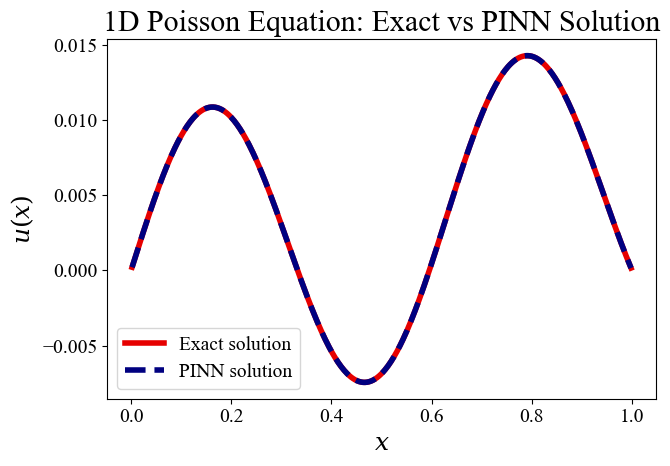

In [193]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "dejavuserif",
    "axes.labelsize": 18,
    "font.size": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

exact_color = "#e60000"   
pinn_color  = "#000080"   

u_pred = model(x.view(-1, 1)).squeeze().detach().cpu()

x_cpu = xc.detach().cpu()
u_exact_cpu = u_exact.detach().cpu()

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(x_cpu,u_exact_cpu,color=exact_color,lw=4,label="Exact solution",zorder=3)

ax.plot(x_cpu,u_pred,color=pinn_color,ls="--",lw=4,label="PINN solution",zorder=4)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(x)$")
ax.set_title("1D Poisson Equation: Exact vs PINN Solution")
ax.legend()
ax.grid(False)

fig.tight_layout()

fig.savefig("pinn_1d_poisson_exact_vs_pinn_solution.png",dpi=300,bbox_inches="tight")

plt.show()

## Plot training loss

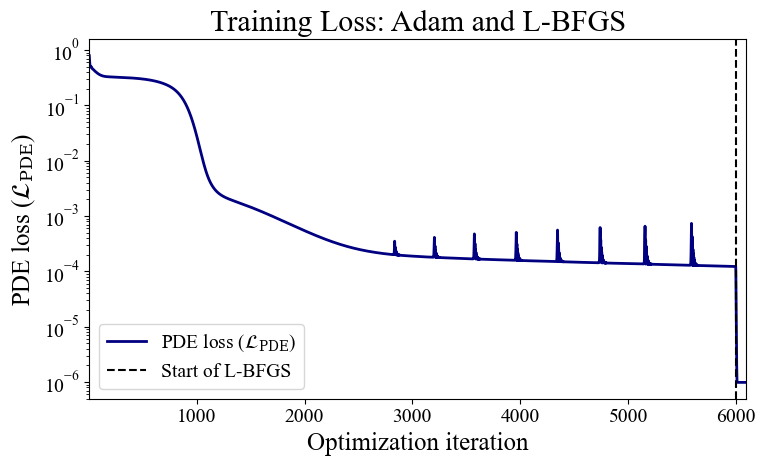

In [196]:
# Iteration numbers start from 1
iterations = np.arange(1, len(loss_history) + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(iterations,loss_history,color="#000080",linewidth=2.0,label=r"PDE loss ($\mathcal{L}_{\mathrm{PDE}}$)")

# Mark the transition from Adam to L-BFGS
ax.axvline(x=num_epochs + 0.5,color="black",linestyle="--",linewidth=1.5,label="Start of L-BFGS")

ax.set_yscale("log")

ax.set_xlabel("Optimization iteration")
ax.set_ylabel(r"PDE loss ($\mathcal{L}_{\mathrm{PDE}}$)")
ax.set_title("Training Loss: Adam and L-BFGS")

ax.set_xlim(1, len(loss_history))

ax.legend(loc="best",frameon=True)

ax.grid(False)

fig.tight_layout()

#fig.savefig("pinn_1d_poisson_training_loss.png",dpi=300,bbox_inches="tight")

plt.show()

## Plot training error

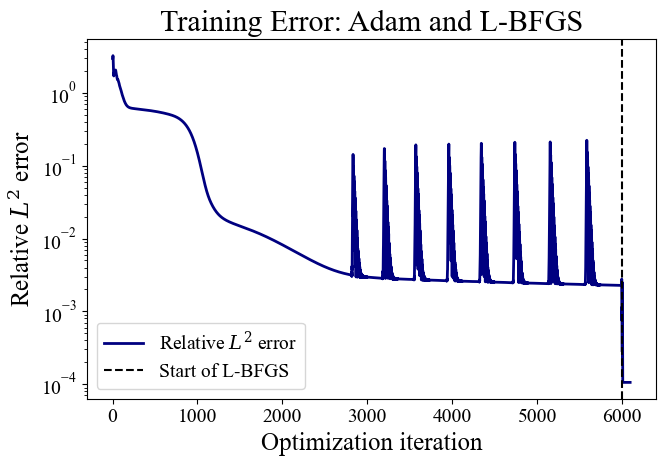

In [199]:
error_color = "#000080"   

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(range(1, len(l2_history) + 1),l2_history,color=error_color,lw=2,label=r"Relative $L^2$ error")

ax.axvline(x=num_epochs,color="black",linestyle="--",linewidth=1.5,label="Start of L-BFGS")

ax.set_yscale("log")
ax.set_xlabel("Optimization iteration")
ax.set_ylabel(r"Relative $L^2$ error")
ax.set_title("Training Error: Adam and L-BFGS")
ax.legend()
ax.grid(False)

fig.tight_layout()
plt.show()

## Figures

<div style="text-align: center;">
    <img src="Tanh.png"
         alt="Neural network architecture and backpropagation"
         width="500">
</div>

<div style="text-align: center;">
    <img src="Power_relu.png"
         alt="Neural network architecture and backpropagation"
         width="500">
</div>

<div style="text-align: center;">
    <img src="LR.png"
         alt="Neural network architecture and backpropagation"
         width="1200">
</div>

<div style="text-align: center;">
    <img src="1D_network.png"
         alt="Neural network architecture and backpropagation"
         width="900">
</div>